# Scenario-Based Stress Testing

This notebook quantifies the sensitivity of CVA, DVA, and BCVA to adverse market scenarios, extending the regime-conditional base case estimates from Notebook 5.

Stress testing is a core component of counterparty credit risk management. While the base-case XVA estimates reflect average market conditions within each historical regime, a CMR framework must also quantify how valuation adjustments behave under tail events that may exceed historically observed market dynamics.

## Scenarios

**Scenario 1 — Credit Spread Widening**
- BBB OAS: +100 bps
- IG OAS: +75 bps
- Rates: unchanged
- Exposure: unchanged

This scenario isolates the pure credit deterioration channel of XVA sensitivity. Only hazard rates are re-calibrated from stressed OAS levels, while discount curves and exposure dynamics remain unchanged.

**Scenario 2 — Market Stress / Volatility Shock**
- BBB OAS: +150 bps
- IG OAS: +100 bps
- Hull-White σ: × 1.5
- Discount curve: unchanged
- Exposure: re-simulated under stressed $\sigma$

This scenario captures acute market dislocation where deteriorating credit conditions occur simultaneously with elevated rate volatility, amplifying both exposure uncertainty and default risk.

**Scenario 3 — Stagflation / Rates + Credit Shock**
- Yield curve: +100 bps parallel shift
- BBB OAS: +150 bps
- IG OAS: +100 bps
- Discount curve: re-computed from shocked yields
- Rate paths: re-simulated under shocked $\theta_t$
- Exposure: re-simulated

This is the most comprehensive stress scenario, simultaneously affecting discounting, exposure dynamics, and default probabilities. The scenario is intended to approximate a persistent high-rate environment accompanied by deteriorating credit quality.

## Methodology

Each scenario is applied as an overlay on top of the four regime-conditional base cases from Notebook 5. For each regime × scenario combination, we:

1. Apply the scenario shocks to relevant inputs
2. Recompute stressed hazard rates where required
3. Recompute stressed discount curves where required
4. Re-simulate exposure profiles where required
5. Recompute UCVA, UDVA, and BCVA
6. Compute $\delta$ XVA = stressed XVA − base XVA

This produces a $4 * 3$ regime-scenario matrix of stress impacts, providing a comprehensive view of CVA sensitivity across both market environments and shock types.

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy.interpolate import CubicSpline
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

np.random.seed(926)

# Load inputs
df = pd.read_csv('../data/processed/main_dataset.csv',index_col='date', parse_dates=True)
regimes = pd.read_csv('../data/processed/regime_labels.csv',index_col='date', parse_dates=True)
hazard_rates = pd.read_csv('../data/processed/regime_hazard_rates.csv')
xva_base = pd.read_csv('../data/processed/xva_results.csv')
exposure_df = pd.read_csv('../data/processed/exposure_profiles.csv')

df = df.join(regimes, how='inner')

# Parameters 
NOTIONAL = 100_000_000
LGD = 0.60
N_PATHS = 1000
N_STEPS = 60
DT = 1/12
CP_RATING  = 'BBB'
OWN_RATING = 'IG'

REGIME_ORDER = [
    'Risk-On',
    'Normalization',
    'Event-Driven Stress',
    'Macro Tightening',
]
REGIME_COLORS = {
    'Risk-On': 'steelblue',
    'Normalization': 'mediumseagreen',
    'Event-Driven Stress': 'darkorange',
    'Macro Tightening': 'crimson',
}
SCENARIO_COLORS = {
    'Base': 'dimgray',
    'Scenario 1\nCredit Spread': 'steelblue',
    'Scenario 2\nMarket Stress': 'darkorange',
    'Scenario 3\nStagflation': 'crimson',
}

YIELD_COLS = ['dgs1mo', 'dgs3mo', 'dgs6mo',
                   'dgs1', 'dgs2', 'dgs3',
                   'dgs5', 'dgs10']
YIELD_TENORS_MO = np.array([1, 3, 6, 12,
                              24, 36, 60, 120])
SIM_TENORS_MO = np.arange(1, 61)

# Reconstruct functions
def calibrate_vasicek(r_series, dt=1/252):
    r = np.array(r_series)
    dr = np.diff(r)
    r_lag  = r[:-1]
    X = np.column_stack([np.ones(len(r_lag)), r_lag])
    coeffs = np.linalg.lstsq(X, dr, rcond=None)[0]
    a, b = coeffs
    kappa = max(-b / dt, 0.001)
    theta = a / (kappa * dt)
    resid = dr - (a + b * r_lag)
    sigma = max(np.std(resid) / np.sqrt(dt), 0.0001)
    return kappa, sigma, theta

def compute_hw_theta(kappa, sigma,
                     yield_curve_pct,
                     sim_tenors_mo,
                     cs_spline=None):
    t = sim_tenors_mo / 12
    if cs_spline is not None:
        r_t = cs_spline(sim_tenors_mo) / 100
        dr_dt = cs_spline.derivative()(sim_tenors_mo) / 100 * 12
        d2r_dt2 = cs_spline.derivative(2)(sim_tenors_mo) / 100 * 144
        f_t = r_t + t * dr_dt
        df_dt = dr_dt + t * d2r_dt2
    else:
        r = yield_curve_pct / 100
        P = np.exp(-r * t)
        ln_P = np.log(P)
        dt_yr = 1/12
        f_t = np.zeros(len(t))
        f_t[0] = -(ln_P[1]-ln_P[0])/dt_yr
        f_t[-1] = -(ln_P[-1]-ln_P[-2])/dt_yr
        f_t[1:-1] = -(ln_P[2:]-ln_P[:-2])/(
                          2*dt_yr)
        df_dt = np.zeros(len(t))
        df_dt[0] = (f_t[1]-f_t[0])/dt_yr
        df_dt[-1] = (f_t[-1]-f_t[-2])/dt_yr
        df_dt[1:-1] = (f_t[2:]-f_t[:-2])/(2*dt_yr)
    convexity = (sigma**2/(2*kappa**2))*(1 - np.exp(-2*kappa*t))
    theta_t = (1/kappa)*df_dt + f_t + convexity
    return theta_t, f_t

def simulate_hull_white(kappa, sigma,
                        theta_t, r0,
                        n_paths, n_steps, dt):
    paths = np.zeros((n_paths, n_steps+1))
    paths[:, 0] = r0
    for t in range(n_steps):
        eps = np.random.randn(n_paths)
        drift = kappa*(theta_t[t]-paths[:,t])*dt
        diff = sigma * np.sqrt(dt) * eps
        paths[:, t+1] = paths[:, t]+drift+diff
    return paths

def compute_irs_value(paths, K, dt=1/12):
    n_paths, n_steps_1 = paths.shape
    n_steps = n_steps_1 - 1
    values  = np.zeros((n_paths, n_steps))
    for t in range(n_steps):
        remaining = paths[:, t+1:]
        n_rem     = remaining.shape[1]
        if n_rem == 0:
            continue
        cum_rates = np.cumsum(
            remaining * dt, axis=1
        )
        df_path = np.exp(-cum_rates)
        net_cf  = (remaining-K)*dt*NOTIONAL
        values[:, t] = np.sum(
            df_path * net_cf, axis=1
        )
    return values

def compute_par_swap_rate(yield_curve_dec,
                           dt=1/12,
                           n_steps=60):
    t_years = np.arange(1, n_steps+1) / 12
    DF = np.exp(-yield_curve_dec * t_years)
    K = (1-DF[-1]) / (np.sum(DF)*dt)
    return K

def compute_xva(epe_profile, ene_profile,
                df_curve, lam_cp, lam_own,
                lgd=0.60, dt=1/12):
    n_steps = len(epe_profile)
    t_mo = np.arange(1, n_steps+1) * dt
    S_cp = np.exp(-lam_cp  * t_mo)
    S_own = np.exp(-lam_own * t_mo)
    S_cp_lag = np.concatenate([[1.0], S_cp[:-1]])
    S_own_lag = np.concatenate([[1.0], S_own[:-1]])
    q_cp = S_cp_lag  - S_cp
    q_own = S_own_lag - S_own

    ucva = -lgd * np.sum(df_curve * epe_profile * q_cp)
    udva = -lgd * np.sum(df_curve * ene_profile * q_own)

    bcva_cva = -lgd * np.sum(df_curve * epe_profile * q_cp * S_own)
    bcva_dva = -lgd * np.sum(df_curve * ene_profile * q_own * S_cp)
    bcva = bcva_cva + bcva_dva
    return ucva, udva, bcva

# Reconstruct regime yield curves
regime_yield_curves = {}
regime_discount_curves = {}
regime_splines = {}
vasicek_params = {}
hw_params = {}

for regime in REGIME_ORDER:
    mask = df['regime_name'] == regime
    mean_yields = df.loc[mask, YIELD_COLS].mean()

    cs = CubicSpline(
        YIELD_TENORS_MO,
        mean_yields.values,
        bc_type='natural'
    )
    regime_splines[regime] = cs

    yc = np.maximum(cs(SIM_TENORS_MO), 0.001)
    regime_yield_curves[regime] = yc

    t_yr = SIM_TENORS_MO / 12
    regime_discount_curves[regime] = np.exp(
        -yc / 100 * t_yr
    )

    # Vasicek calibration
    r_data = df.loc[mask, 'dgs1mo'].dropna()/100
    kappa, sigma, theta = calibrate_vasicek(
        r_data, dt=1/252
    )
    vasicek_params[regime] = {
        'kappa': kappa,
        'sigma': sigma,
        'theta': theta,
    }

    # HW theta
    theta_t, _ = compute_hw_theta(
        kappa, sigma, yc, SIM_TENORS_MO,
        cs_spline=cs
    )
    hw_params[regime] = {
        'kappa': kappa,
        'sigma': sigma,
        'theta_t': theta_t,
    }

# Reconstruct base EPE/ENE 
epe_profiles = {}
ene_profiles = {}

for regime in REGIME_ORDER:
    subset = exposure_df[
        exposure_df['regime'] == regime
    ].sort_values('tenor')
    epe_profiles[regime] = subset['epe'].values
    ene_profiles[regime] = subset['ene'].values

# Unified K
full_yc_dec = np.array([
    df[col].mean()/100 for col in YIELD_COLS
])
cs_full = CubicSpline(
    YIELD_TENORS_MO,
    full_yc_dec * 100,
    bc_type='natural'
)
full_yc_interp = np.maximum(
    cs_full(SIM_TENORS_MO)/100, 0.001
)
K_UNIFIED = compute_par_swap_rate(full_yc_interp)

#  Base hazard rates
base_lambda = {}
for regime in REGIME_ORDER:
    base_lambda[regime] = {
        'cp':  hazard_rates.loc[
            (hazard_rates['regime'] == regime) &
            (hazard_rates['rating'] == CP_RATING),
            'lambda'
        ].values[0],
        'own': hazard_rates.loc[
            (hazard_rates['regime'] == regime) &
            (hazard_rates['rating'] == OWN_RATING),
            'lambda'
        ].values[0],
    }

print(f"\nUnified K: {K_UNIFIED*100:.4f}%")
print(f"\nBase hazard rates:")
print(f"{'Regime':<22} {'lambda_cp (BBB)':>12} "
      f"{'lambda_own (IG)':>12}")
print("-"*50)
for regime in REGIME_ORDER:
    print(f"{regime:<22} "
          f"{base_lambda[regime]['cp']:>12.6f} "
          f"{base_lambda[regime]['own']:>12.6f}")

print(f"\nBase XVA:")
print(xva_base[['regime','ucva',
                'udva','bcva']].to_string(
    index=False
))


Unified K: 3.4595%

Base hazard rates:
Regime                 lambda_cp (BBB) lambda_own (IG)
--------------------------------------------------
Risk-On                    0.017675     0.014130
Normalization              0.020339     0.016372
Event-Driven Stress        0.023490     0.019030
Macro Tightening           0.029689     0.023995

Base XVA:
             regime          ucva         udva          bcva
            Risk-On -54572.107204 28560.447711 -25286.279529
      Normalization -10616.119231 27132.512463  15831.863414
Event-Driven Stress -58591.596191 36105.885760 -21910.650122
   Macro Tightening -17011.917693 53106.525667  33722.595941


## Baseline Inputs

We establish the regime-conditional base case inputs as the reference for all stress comparisons. Base case values are consistent with Notebook 5 outputs.

In [18]:
# base XVA 
print("Base Case")
print("="*95)
print(f"{'Regime':<22} {'λ_cp':>7} "
      f"{'λ_own':>8} {'σ':>6} "
      f"{'UCVA ($)':>14} {'UDVA ($)':>12} "
      f"{'BCVA ($)':>12}")
print("-"*95)

base_xva = {}

for regime in REGIME_ORDER:
    lam_cp = base_lambda[regime]['cp']
    lam_own = base_lambda[regime]['own']
    sigma = hw_params[regime]['sigma']

    ucva, udva, bcva = compute_xva(
        epe_profiles[regime],
        ene_profiles[regime],
        regime_discount_curves[regime],
        lam_cp, lam_own, LGD
    )

    base_xva[regime] = {
        'ucva': ucva,
        'udva': udva,
        'bcva': bcva,
    }

    print(f"{regime:<22} "
          f"{lam_cp:>8.4f} "
          f"{lam_own:>8.4f} "
          f"{sigma:>8.4f} "
          f"{ucva:>12,.2f} "
          f"{udva:>12,.2f} "
          f"{bcva:>12,.2f}")

Base Case
Regime                    λ_cp    λ_own      σ       UCVA ($)     UDVA ($)     BCVA ($)
-----------------------------------------------------------------------------------------------
Risk-On                  0.0177   0.0141   0.0343   -54,572.11    28,560.45   -25,286.28
Normalization            0.0203   0.0164   0.0071   -10,616.12    27,132.51    15,831.86
Event-Driven Stress      0.0235   0.0190   0.0504   -58,591.60    36,105.89   -21,910.65
Macro Tightening         0.0297   0.0240   0.0191   -17,011.92    53,106.53    33,722.60


## Scenarios

We define three stress scenarios as parameter overlays applied to the base case inputs. Each scenario is designed to capture a distinct credit risk transmission channel.

| Parameter        | Base | Scenario 1    | Scenario 2    | Scenario 3 |
|------------------|------|---------------|---------------|------------|
| BBB OAS shock    | No Shock | +100 bps      | +150 bps      | +150 bps   |
| IG OAS shock     | No Shock | +75 bps       | +100 bps      | +100 bps   |
| Rate shift       | No Shock |  No Shock     | No Shock      |  +100 bps  |
| HW $\sigma$ multiplier  | 1.0× | 1.0×   | 1.5×          | 1.0×       |
| Discount curve   | Base | Base          | Base          | Shocked    |
| Exposure profile | Base | Base          | Re-simulated  | Re-simulated |
| Hazard rates     | Base | Re-calibrated | Re-calibrated | Re-calibrated |

In [29]:
# Scenario parameter
SCENARIOS = {
    'Scenario 1 \n Credit Spread': {
        'label': 'Scenario 1: Credit Spread Widening',
        'doas_cp_bps':  100,
        'doas_own_bps': 75,
        'rate_shift_bps': 0.0,
        'vol_mult': 1.0,
        'reshock_df': False,
        'resim_epe': False,
    },
    'Scenario 2 \n Market Stress': {
        'label': 'Scenario 2: Market Stress',
        'doas_cp_bps': 150,
        'doas_own_bps': 100,
        'rate_shift_bps': 0.0,
        'vol_mult': 1.5,
        'reshock_df': False,
        'resim_epe': True,
    },
    'Scenario 3 \n Stagflation': {
        'label': 'Scenario 3: Stagflation',
        'doas_cp_bps': 150,
        'doas_own_bps': 100,
        'rate_shift_bps': 100.0,   # +100 bps = +1.0%
        'vol_mult': 1.0,
        'reshock_df': True,
        'resim_epe': True,
    },
}

print("Scenario Definitions")
print("="*75)
for key, params in SCENARIOS.items():
    print(f"\n{params['label']}")
    print(f"  BBB OAS shock:     "
          f"+{params['doas_cp_bps']} bps")
    print(f"  IG OAS shock:      "
          f"+{params['doas_own_bps']} bps")
    print(f"  Rate shift:        "
          f"+{params['rate_shift_bps']:.0f} bps")
    print(f"  Vol multiplier:    "
          f"{params['vol_mult']}×")
    print(f"  Reshock DF:        "
          f"{params['reshock_df']}")
    print(f"  Re-simulate EPE:    "
          f"{params['resim_epe']}")

# ---------------------------------------------------
# Stressed hazard rate from OAS shock
# ---------------------------------------------------
def stressed_lambda(lam_base, doas_bps, lgd=0.60):
    """
    Re-calibrate hazard rate from shocked OAS.

    OAS_base (bps) = lam_base * LGD * 10000
    OAS_stressed   = OAS_base + ΔOAS
    λ_stressed     = OAS_stressed / (LGD * 10000)
    """
    oas_base_bps = lam_base * lgd * 10000
    oas_stressed = oas_base_bps + doas_bps
    return oas_stressed / (lgd * 10000)

# ---------------------------------------------------
# Stressed discount curve
# ---------------------------------------------------
def stressed_discount_curve(regime, rate_shift_bps):
    """
    Apply parallel rate shift to regime yield curve and recompute discount factors.

    Parameters
    regime : str
    rate_shift_bps : float, Shift in basis points
    """
    yc_base   = regime_yield_curves[regime]
    yc_shocked = np.maximum(yc_base + rate_shift_bps / 100, 0.001)
    t_yr = SIM_TENORS_MO / 12
    return np.exp(-yc_shocked / 100 * t_yr)

# ---------------------------------------------------
# Re-simulate exposure under stressed volatility and/or rate shift
# ---------------------------------------------------
def stressed_exposure(regime, vol_mult, rate_shift_bps=0.0):
    """
    Re-simulate Hull-White paths under stressed parameters, then recompute EPE/ENE profiles.

    Parameters
    ----------
    regime : str
    vol_mult : float, Multiplier applied to base sigma
    rate_shift_bps : float
        Parallel yield curve shift in basis points
        Also shocks r0 and K for consistency.
    """
    kappa   = hw_params[regime]['kappa']
    sigma_s = hw_params[regime]['sigma'] * vol_mult
    yc_base = regime_yield_curves[regime]

    if rate_shift_bps != 0.0:
        # Shock yield curve at original 8 nodes
        mean_yields_pct = df.loc[
            df['regime_name'] == regime,
            YIELD_COLS
        ].mean().values

        yc_nodes_shocked_pct = np.maximum(mean_yields_pct + rate_shift_bps / 100, 0.001)

        # Rebuild spline from shocked nodes
        cs_shocked = CubicSpline(YIELD_TENORS_MO, yc_nodes_shocked_pct, bc_type='natural')

        # Shocked interpolated yield curve
        yc_shocked_pct = np.maximum(cs_shocked(SIM_TENORS_MO), 0.001)

        # Recompute theta(t) from shocked curve
        theta_t, _ = compute_hw_theta(
            kappa, sigma_s,
            yc_shocked_pct, SIM_TENORS_MO,
            cs_spline=cs_shocked
        )

        # r0: shock initial short rate
        r0 = (
            df.loc[df['regime_name'] == regime, 'dgs1mo'].mean() / 100 + rate_shift_bps / 10000
        )

        # K: recompute par rate from shocked curve
        K = compute_par_swap_rate(np.maximum(yc_shocked_pct / 100, 0.001))

    else:
        # Base case: use existing theta_t
        theta_t = hw_params[regime]['theta_t']

        r0 = df.loc[df['regime_name'] == regime, 'dgs1mo'].mean() / 100

        # Regime-specific base K
        K = compute_par_swap_rate(np.maximum(yc_base / 100, 0.001))

    # Simulate paths
    paths = simulate_hull_white(
        kappa, sigma_s, theta_t, r0, N_PATHS, N_STEPS, DT
    )

    # IRS valuation
    values = compute_irs_value(paths, K)

    # EPE and ENE
    epe = np.mean(np.maximum(values, 0), axis=0)
    ene = np.mean(np.minimum(values, 0), axis=0)

    return epe, ene

Scenario Definitions

Scenario 1: Credit Spread Widening
  BBB OAS shock:     +100 bps
  IG OAS shock:      +75 bps
  Rate shift:        +0 bps
  Vol multiplier:    1.0×
  Reshock DF:        False
  Re-simulate EPE:    False

Scenario 2: Market Stress
  BBB OAS shock:     +150 bps
  IG OAS shock:      +100 bps
  Rate shift:        +0 bps
  Vol multiplier:    1.5×
  Reshock DF:        False
  Re-simulate EPE:    True

Scenario 3: Stagflation
  BBB OAS shock:     +150 bps
  IG OAS shock:      +100 bps
  Rate shift:        +100 bps
  Vol multiplier:    1.0×
  Reshock DF:        True
  Re-simulate EPE:    True



## Hazard Rate Shock Calculation

Stressed hazard rates are re-calibrated directly from shocked OAS levels for each regime and scenario:

$$\lambda^{stressed} = \frac{OAS_{base} + \Delta OAS}{LGD \times 10{,}000}$$

, where \(OAS_{\text{base}}\) and \(\Delta OAS\) are expressed in basis points.

In [30]:
# Store stressed hazard rates for all scenarios
stressed_lambdas = {}

print("Stressed Hazard Rates")
print("="*95)

for scenario_key, params in SCENARIOS.items():
    stressed_lambdas[scenario_key] = {}
    print(f"\n{params['label']}")
    print(f" {'Regime':<22} "
          f"{'λ_cp base':>10} "
          f"{'λ_cp stressed':>14} "
          f"{'λ_own base':>11} "
          f"{'λ_own stressed':>15}")
    print(f"  {'-'*92}")

    for regime in REGIME_ORDER:
        lam_cp_base = base_lambda[regime]['cp']
        lam_own_base = base_lambda[regime]['own']

        lam_cp_s = stressed_lambda(
            lam_cp_base,
            params['doas_cp_bps'],
            LGD
        )
        lam_own_s = stressed_lambda(
            lam_own_base,
            params['doas_own_bps'],
            LGD
        )

        stressed_lambdas[scenario_key][regime] = {
            'cp': lam_cp_s,
            'own': lam_own_s,
        }

        print(f"{regime:<22} "
              f"{lam_cp_base:>10.6f} "
              f"{lam_cp_s:>14.6f} "
              f"{lam_own_base:>11.6f} "
              f"{lam_own_s:>15.6f}")

        # Print implied 1Y PD for both counterparty and own
        pd_cp_base = 1 - np.exp(-lam_cp_base)
        pd_cp_s = 1 - np.exp(-lam_cp_s)

        pd_own_base = 1 - np.exp(-lam_own_base)
        pd_own_s = 1 - np.exp(-lam_own_s)

        print(f"  {'':22} "
              f"{'CP PD(1Y):':>10} "
              f"{pd_cp_base*100:>8.4f}% ->"
              f"{pd_cp_s*100:>8.4f}%  "
              f"{'Own PD(1Y):':>11} "
              f"{pd_own_base*100:>8.4f}% -> "
              f"{pd_own_s*100:>8.4f}%")
        print()

Stressed Hazard Rates

Scenario 1: Credit Spread Widening
 Regime                  λ_cp base  λ_cp stressed  λ_own base  λ_own stressed
  --------------------------------------------------------------------------------------------
Risk-On                  0.017675       0.034341    0.014130        0.026630
                         CP PD(1Y):   1.7519% ->  3.3758%  Own PD(1Y):   1.4031% ->   2.6279%

Normalization            0.020339       0.037006    0.016372        0.028872
                         CP PD(1Y):   2.0134% ->  3.6330%  Own PD(1Y):   1.6239% ->   2.8460%

Event-Driven Stress      0.023490       0.040156    0.019030        0.031530
                         CP PD(1Y):   2.3216% ->  3.9361%  Own PD(1Y):   1.8850% ->   3.1038%

Macro Tightening         0.029689       0.046355    0.023995        0.036495
                         CP PD(1Y):   2.9252% ->  4.5297%  Own PD(1Y):   2.3709% ->   3.5837%


Scenario 2: Market Stress
 Regime                  λ_cp base  λ_cp stressed  λ_o

Stress scenarios materially increase both counterparty and own implied hazard rates across all regimes, with the largest increases observed under the Market Stress and Stagflation scenarios.

**Scenario 1 — Credit Spread Widening**

Under a pure credit spread widening shock (+100 bps BBB OAS, +75 bps IG OAS), counterparty hazard rates approximately double across all regimes. For example, in the Risk-On regime, the BBB hazard rate increases from 1.77% to 3.43%, corresponding to a rise in 1Y implied PD from 1.75% to 3.38%.

Macro Tightening remains the riskiest regime after stress, with the stressed BBB 1Y PD increasing from 2.93% to 4.53%. Own-credit hazard rates also increase materially, although less aggressively than the counterparty due to the smaller IG OAS shock.

**Scenario 2 — Market Stress**

The Market Stress scenario applies a more severe credit shock (+150 bps BBB OAS, +100 bps IG OAS) together with a volatility shock. Hazard rate recalibration produces substantially higher implied default probabilities across all regimes.

In the Event-Driven Stress regime, the BBB 1Y implied PD rises from 2.32% to 4.73%, while Macro Tightening reaches the highest stressed BBB PD of 5.32%. IG own-credit PDs also rise significantly, reaching nearly 4.0% in Macro Tightening.

The results indicate that under acute market dislocations, both counterparty and own credit quality deteriorate rapidly, materially increasing bilateral credit valuation risk.

**Scenario 3 — Stagflation**

The Stagflation scenario produces identical stressed hazard rates to Scenario 2 because the credit spread shocks are unchanged. However, unlike Scenario 2, this scenario also shocks the yield curve (+100 bps parallel shift) and re-simulates the exposure profile under the stressed rate environment.

As a result, Scenario 3 differs from Scenario 2 not through the PD channel, but through the simultaneous interaction between higher hazard rates, shocked discount factors, and altered exposure dynamics. This makes Stagflation the most comprehensive stress scenario in the framework, simultaneously affecting all major XVA drivers.

## Recompute Stressed Discount Curves and Exposure Profiles

For scenarios requiring re-estimation of discount curves or exposure profiles, we apply the relevant shocks and recompute the inputs before XVA calculation.

- **Scenario 1**: discount curve and exposure unchanged
- **Scenario 2**: exposure re-simulated under stressed $\sigma$ (×1.5), discount curve unchanged
- **Scenario 3**: both discount curve and exposure re-computed under +100 bps rate shift

In [35]:
# Store stressed discount curves and exposure profiles for all scenarios
stressed_df_curves = {}
stressed_epe = {}
stressed_ene = {}

print("Computing stressed discount curves and exposure profiles")
print("="*85)

for scenario_key, params in SCENARIOS.items():
    stressed_df_curves[scenario_key] = {}
    stressed_epe[scenario_key] = {}
    stressed_ene[scenario_key] = {}

    print(f"\n{params['label']}")

    for regime in REGIME_ORDER:

        # Discount curve
        if params['reshock_df']:
            df_curve = stressed_discount_curve(regime, params['rate_shift_bps'])
            print(f"{regime:<22} "
                  f"DF shocked  "
                  f"DF(5Y): "
                  f"{df_curve[-1]:.4f} "
                  f"(base: "
                  f"{regime_discount_curves[regime][-1]:.4f})")
        else:
            df_curve = regime_discount_curves[regime]
            print(f"{regime:<22} "
                  f"DF base     "
                  f"DF(5Y): "
                  f"{df_curve[-1]:.4f}")

        stressed_df_curves[scenario_key][regime] = (df_curve)

        # Exposure profile
        if params['resim_epe']:
            epe, ene = stressed_exposure(
                regime,
                params['vol_mult'],
                params['rate_shift_bps']
            )
            peak_epe = epe.max() / 1e6
            print(f" {'':22} "
                  f"Exposure re-sim   "
                  f"Peak EPE: ${peak_epe:.3f}M "
                  f"(base: "
                  f"${epe_profiles[regime].max()/1e6:.3f}M)")
            print()
        else:
            epe = epe_profiles[regime]
            ene = ene_profiles[regime]
            print(f" {'':22} "
                  f"Exposure base     "
                  f"Peak EPE: "
                  f"${epe.max()/1e6:.3f}M")
            print()

        stressed_epe[scenario_key][regime] = epe
        stressed_ene[scenario_key][regime] = ene

Computing stressed discount curves and exposure profiles

Scenario 1: Credit Spread Widening
Risk-On                DF base     DF(5Y): 0.8759
                        Exposure base     Peak EPE: $1.428M

Normalization          DF base     DF(5Y): 0.8121
                        Exposure base     Peak EPE: $0.479M

Event-Driven Stress    DF base     DF(5Y): 0.8586
                        Exposure base     Peak EPE: $1.276M

Macro Tightening       DF base     DF(5Y): 0.8276
                        Exposure base     Peak EPE: $0.546M


Scenario 2: Market Stress
Risk-On                DF base     DF(5Y): 0.8759
                        Exposure re-sim   Peak EPE: $2.030M (base: $1.428M)

Normalization          DF base     DF(5Y): 0.8121
                        Exposure re-sim   Peak EPE: $1.258M (base: $0.479M)

Event-Driven Stress    DF base     DF(5Y): 0.8586
                        Exposure re-sim   Peak EPE: $1.648M (base: $1.276M)

Macro Tightening       DF base     DF(5Y): 0.8276
     

Scenario 1 leaves discount curves and exposure profiles unchanged by construction, since it isolates the credit spread channel.

Scenario 2 increases Hull-White volatility by 50% and re-simulates exposure profiles. Peak EPE rises across all regimes, confirming that higher rate volatility increases positive exposure uncertainty. The increase is especially pronounced in Normalization, where the base-case volatility is low and the exposure profile is therefore highly sensitive to volatility shocks.

Scenario 3 applies a +100 bps parallel yield curve shift and re-simulates rate paths and exposures. Discount factors decline across all regimes, with 5Y discount factors falling by roughly 4 percentage points. Peak EPE responses are mixed because the rate shock affects several channels simultaneously: the initial short rate, Hull-White drift, par swap rate, discount curve, and simulated exposure profile.

Overall, the stress outputs behave consistently with the scenario design: credit-only shocks affect hazard rates only, volatility shocks increase exposure dispersion, and stagflation shocks affect both discounting and exposure dynamics.

## Recompute Stressed XVA

We combine the stressed hazard rates from Section 4, stressed discount curves and exposure profiles from Section 5 to recompute UCVA, UDVA, and BCVA under each scenario.

For each regime $\times$ scenario combination:

$$UCVA^{stressed} = -LGD \sum_t DF^{stressed}(t) \cdot EPE^{stressed}(t) \cdot q_C^{stressed}(t-1,t)$$

The stressed $\Delta$ XVA is then computed as the deviation from the base case:

$$\Delta XVA = XVA^{stressed} - XVA^{base}$$

A negative $\Delta$ UCVA indicates CVA charge increases (more negative), representing additional credit cost under stress.

In [51]:
# Store stressed XVA results
stressed_xva = {}
delta_xva = {}

all_results = []

print("Stressed XVA Results")
print("="*110)

for scenario_key, params in SCENARIOS.items():
    stressed_xva[scenario_key] = {}
    delta_xva[scenario_key]    = {}

    print(f"\n{params['label']}")
    print(f"{'Regime':<22} "
          f"{'UCVA':>11} {'ΔUCVA':>14} "
          f"{'UDVA':>11} {'ΔUDVA':>14} "
          f"{'BCVA':>12} {'ΔBCVA':>13}")
    print(f"{'-'*110}")

    for regime in REGIME_ORDER:
        # Stressed inputs
        lam_cp_s = stressed_lambdas[scenario_key][regime]['cp']
        lam_own_s = stressed_lambdas[scenario_key][regime]['own']

        df_curve = stressed_df_curves[scenario_key][regime]

        epe = stressed_epe[scenario_key][regime]
        ene = stressed_ene[scenario_key][regime]

        # Compute stressed XVA
        ucva_s, udva_s, bcva_s = compute_xva(epe, ene, df_curve, lam_cp_s, lam_own_s, LGD)

        # Base XVA
        ucva_b = base_xva[regime]['ucva']
        udva_b = base_xva[regime]['udva']
        bcva_b = base_xva[regime]['bcva']

        # Delta XVA
        d_ucva = ucva_s - ucva_b
        d_udva = udva_s - udva_b
        d_bcva = bcva_s - bcva_b

        stressed_xva[scenario_key][regime] = {
            'ucva': ucva_s,
            'udva': udva_s,
            'bcva': bcva_s,
        }
        delta_xva[scenario_key][regime] = {
            'ducva': d_ucva,
            'dudva': d_udva,
            'dbcva': d_bcva,
        }

        print(f"  {regime:<22} "
              f"{ucva_s:>12,.2f} "
              f"{d_ucva:>+13,.2f} "
              f"{udva_s:>12,.2f} "
              f"{d_udva:>+13,.2f} "
              f"{bcva_s:>12,.2f} "
              f"{d_bcva:>+13,.2f}")

        all_results.append({
            'scenario': params['label'],
            'regime': regime,
            'ucva': ucva_s,
            'udva': udva_s,
            'bcva': bcva_s,
            'delta_ucva': d_ucva,
            'delta_udva': d_udva,
            'delta_bcva': d_bcva,
        })

results_stressed_df = pd.DataFrame(all_results)

Stressed XVA Results

Scenario 1: Credit Spread Widening
Regime                        UCVA          ΔUCVA        UDVA          ΔUDVA         BCVA         ΔBCVA
--------------------------------------------------------------------------------------------------------------
  Risk-On                 -102,557.51    -47,985.40    52,743.65    +24,183.20   -47,352.28    -22,066.00
  Normalization            -18,777.72     -8,161.60    46,797.24    +19,664.73    25,925.26    +10,093.40
  Event-Driven Stress      -97,034.45    -38,442.85    58,463.15    +22,357.27   -37,065.00    -15,154.35
  Macro Tightening         -25,855.35     -8,843.43    78,824.67    +25,718.15    47,634.58    +13,911.98

Scenario 2: Market Stress
Regime                        UCVA          ΔUCVA        UDVA          ΔUDVA         BCVA         ΔBCVA
--------------------------------------------------------------------------------------------------------------
  Risk-On                 -176,023.91   -121,451.80   105,003.

Stress scenarios materially amplify both unilateral and bilateral XVA measures across all regimes, with the magnitude and direction of the impact depending strongly on the underlying exposure profile and yield curve environment.

**Scenario 1 — Credit Spread Widening**

Under the pure credit spread widening scenario, both UCVA and UDVA increase materially in absolute value across all regimes due to the higher stressed hazard rates.

UCVA becomes substantially more negative, especially in Risk-On and Event-Driven Stress, where large positive exposure profiles amplify the counterparty default component. Risk-On BCVA declines from -$25.3k to -$47.4k, while Event-Driven Stress declines from -$21.9k to -$37.1k. At the same time, UDVA rises across all regimes because the stressed own-credit hazard rate increases the DVA benefit. However, in Risk-On and Event-Driven Stress, the increase in UCVA dominates the increase in UDVA, producing more negative BCVA overall. In contrast, Normalization and Macro Tightening remain DVA-dominated regimes even after stress. BCVA increases further to +$25.9k and +$47.6k respectively, reflecting the structurally larger ENE profiles under inverted yield curve conditions.

**Scenario 2 — Market Stress**

Scenario 2 produces the most severe deterioration in bilateral XVA across most regimes because it simultaneously shocks both hazard rates and exposure volatility.

The 50% increase in Hull-White volatility materially increases EPE profiles across all regimes, amplifying the CVA component. Risk-On UCVA deteriorates from -$54.6k to -$176.0k, while Event-Driven Stress deteriorates to -$152.5k. Normalization experiences the largest relative deterioration in BCVA. The regime transitions from a positive BCVA (+$15.8k base case) to a strongly negative stressed BCVA (-$26.9k), indicating that volatility-driven exposure expansion overwhelms the DVA benefit previously generated by the inverted curve environment. Macro Tightening remains comparatively resilient. Although UCVA deteriorates significantly, the regime still retains a positive BCVA (+$31.8k) due to the persistently large ENE profile and elevated DVA contribution.

**Scenario 3 — Stagflation**

The stagflation scenario combines credit spread widening with a parallel upward shift in the yield curve, simultaneously affecting hazard rates, discount factors, and exposure dynamics.

Relative to Scenario 2, the higher discount rates partially offset the increase in stressed exposure by reducing the present value of future cash flows. As a result, BCVA deterioration is generally less severe than in the pure volatility-driven market stress scenario.

Risk-On and Event-Driven Stress remain strongly CVA-dominated, with stressed BCVA reaching -$55.8k and -$49.2k respectively. Normalization again exhibits the largest regime transition effect. BCVA reverses from a positive base case (+$15.8k) to a materially negative stressed value (-$19.9k), demonstrating that the inverted curve benefit can disappear once both rates and credit spreads deteriorate simultaneously. Macro Tightening remains the only regime with persistently positive BCVA across all scenarios, although the stressed BCVA increase (+$3.4k relative to base) is much smaller than under Scenario 1 because the higher discount rates partially compress the DVA benefit.

Overall, the stress testing results demonstrate that regime structure materially affects not only base-case XVA levels, but also the transmission of macro-financial shocks into bilateral credit valuation adjustments. Normal curve regimes remain highly sensitive to volatility-driven EPE expansion, while inverted curve regimes exhibit greater DVA resilience due to structurally larger negative exposure profiles.

## Scenario Impact Comparison

We visualize the stressed XVA results across all regime $\times$ scenario combinations to provide a comprehensive picture of CVA sensitivity to market stress.

Three charts are produced:

1. Absolute XVA levels: base case vs. all three stressed scenarios for UCVA, UDVA, and BCVA
2. $\Delta$ XVA heatmap: incremental impact of each scenario relative to base, showing which regime $\times$ scenario combinations produce the largest stress amplification
3. BCVA waterfall: decomposition of stressed BCVA into CVA and DVA components across scenarios

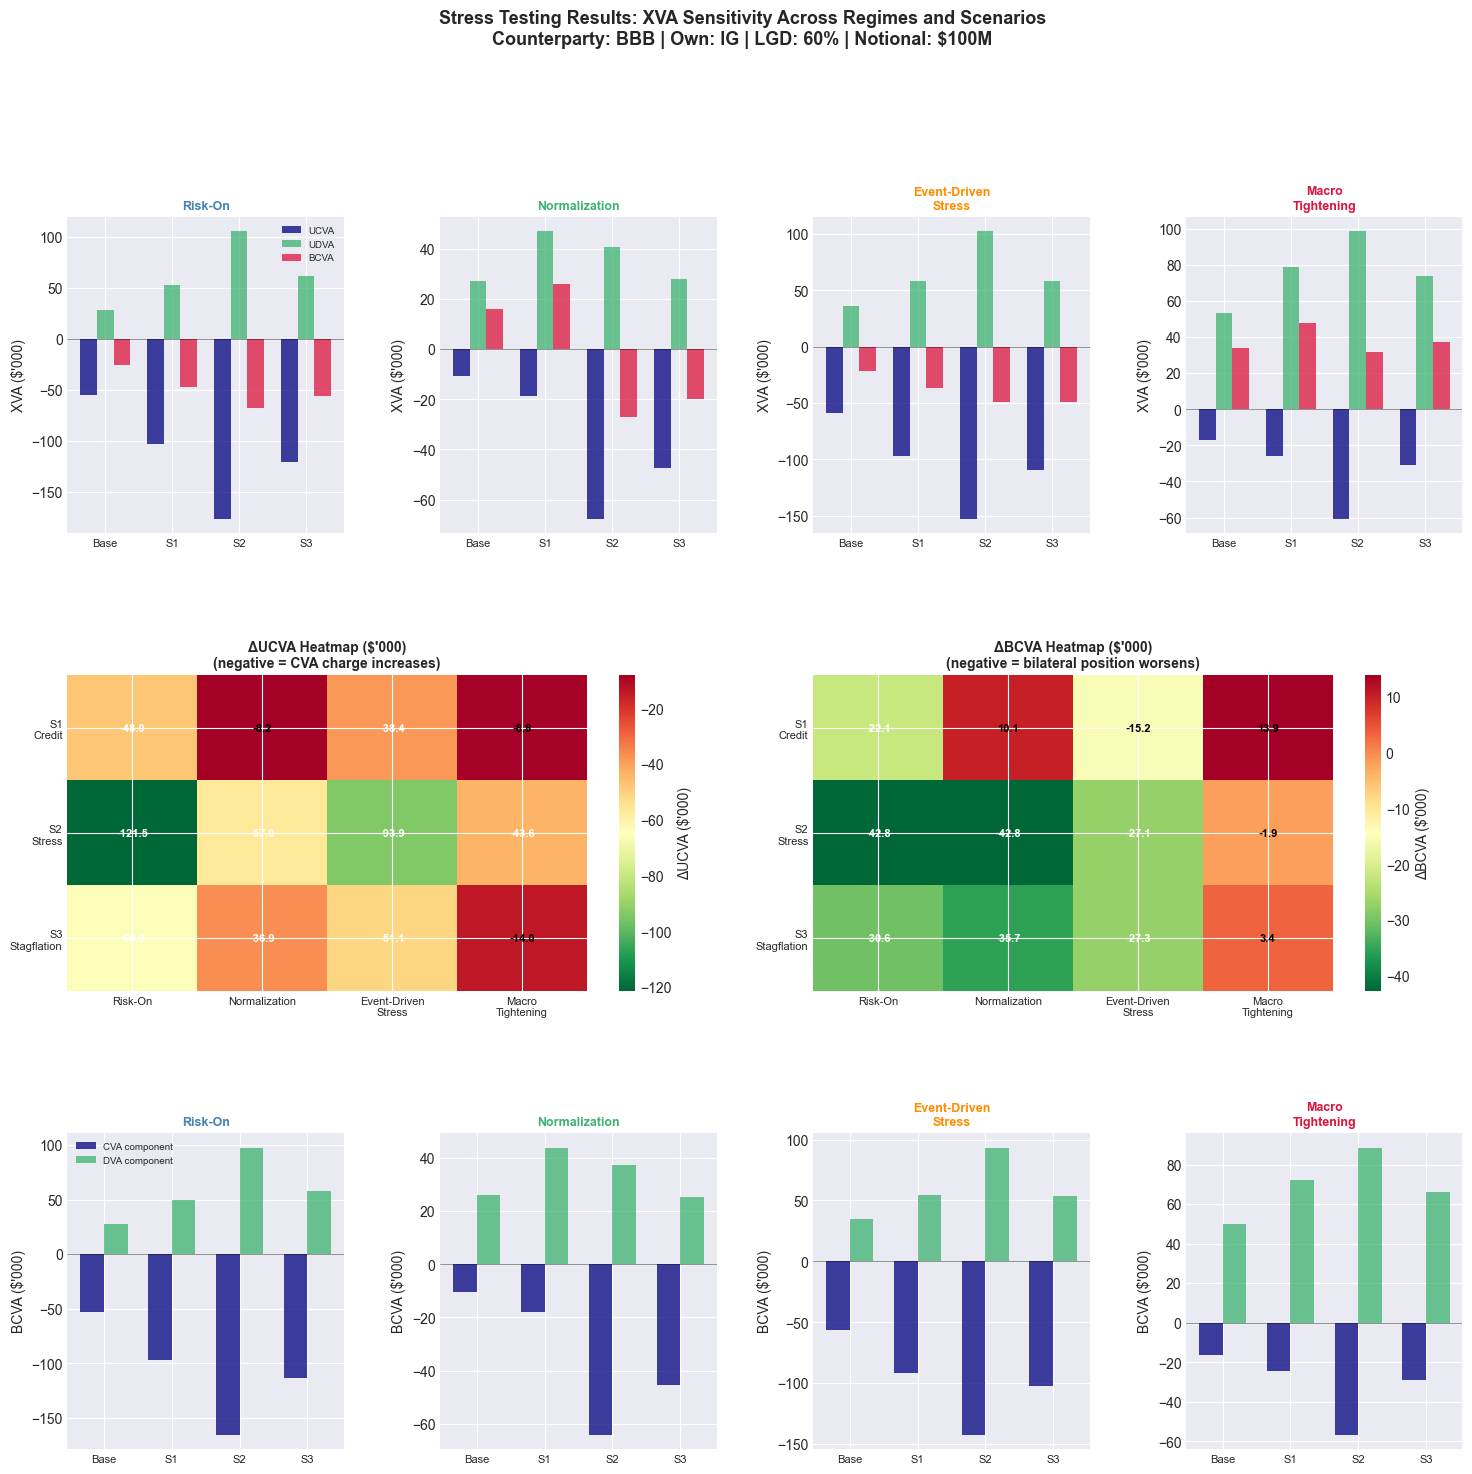

In [ ]:
fig = plt.figure(figsize=(18, 16))
gs  = fig.add_gridspec(3, 4, hspace=0.45, wspace=0.35)

scenario_labels = ['Base'] + [k.replace('\n', ' ') for k in SCENARIOS.keys()]
scenario_colors_list = ['dimgray', 'steelblue', 'darkorange', 'crimson']

# ================================================
# Plot 1-4: XVA by regime
# ================================================
for col, regime in enumerate(REGIME_ORDER):
    ax = fig.add_subplot(gs[0, col])

    # Collect values: base + 3 scenarios
    ucva_vals = [base_xva[regime]['ucva']/1000]
    udva_vals = [base_xva[regime]['udva']/1000]
    bcva_vals = [base_xva[regime]['bcva']/1000]

    for key in SCENARIOS:
        ucva_vals.append(
            stressed_xva[key][regime]['ucva']/1000
        )
        udva_vals.append(
            stressed_xva[key][regime]['udva']/1000
        )
        bcva_vals.append(
            stressed_xva[key][regime]['bcva']/1000
        )

    x = np.arange(4)
    width = 0.25

    ax.bar(x - width, ucva_vals, width,
           label='UCVA', color='navy',
           alpha=0.75)
    ax.bar(x, udva_vals, width,
           label='UDVA', color='mediumseagreen',
           alpha=0.75)
    ax.bar(x + width,  bcva_vals, width,
           label='BCVA', color='crimson',
           alpha=0.75)

    ax.set_title(
        regime.replace(' ', '\n'),
        fontsize=9, fontweight='bold',
        color=REGIME_COLORS[regime]
    )
    ax.set_xticks(x)
    ax.set_xticklabels(
        ['Base', 'S1', 'S2', 'S3'],
        fontsize=8
    )
    ax.set_ylabel("XVA ($'000)")
    ax.axhline(y=0, color='black',
               linewidth=0.6, alpha=0.5)
    if col == 0:
        ax.legend(fontsize=7)

# ================================================
# Plot 5-6: ΔUCVA and ΔBCVA heatmaps
# ================================================
scenario_short = ['S1\nCredit', 
                  'S2\nStress',
                  'S3\nStagflation']

# ΔUCVA heatmap
ax_h1 = fig.add_subplot(gs[1, :2])
ducva_matrix = np.array([
    [delta_xva[key][regime]['ducva']/1000
     for regime in REGIME_ORDER]
    for key in SCENARIOS
])

im1 = ax_h1.imshow(
    ducva_matrix, cmap='RdYlGn_r',
    aspect='auto'
)
plt.colorbar(im1, ax=ax_h1,
             label="ΔUCVA ($'000)")
ax_h1.set_xticks(range(len(REGIME_ORDER)))
ax_h1.set_xticklabels(
    [r.replace(' ', '\n') 
     for r in REGIME_ORDER],
    fontsize=8
)
ax_h1.set_yticks(range(3))
ax_h1.set_yticklabels(scenario_short,
                       fontsize=8)
ax_h1.set_title('ΔUCVA Heatmap ($\'000)\n'
                '(negative = CVA charge increases)',
                fontsize=10, fontweight='bold')

for i in range(3):
    for j in range(4):
        ax_h1.text(
            j, i,
            f"{ducva_matrix[i,j]:.1f}",
            ha='center', va='center',
            fontsize=8, fontweight='bold',
            color='white' if abs(
                ducva_matrix[i,j]
            ) > 30 else 'black'
        )

# ΔBCVA heatmap
ax_h2 = fig.add_subplot(gs[1, 2:])
dbcva_matrix = np.array([
    [delta_xva[key][regime]['dbcva']/1000
     for regime in REGIME_ORDER]
    for key in SCENARIOS
])

im2 = ax_h2.imshow(
    dbcva_matrix, cmap='RdYlGn_r',
    aspect='auto'
)
plt.colorbar(im2, ax=ax_h2,
             label="ΔBCVA ($'000)")
ax_h2.set_xticks(range(len(REGIME_ORDER)))
ax_h2.set_xticklabels(
    [r.replace(' ', '\n') 
     for r in REGIME_ORDER],
    fontsize=8
)
ax_h2.set_yticks(range(3))
ax_h2.set_yticklabels(scenario_short,
                       fontsize=8)
ax_h2.set_title('ΔBCVA Heatmap ($\'000)\n'
                '(negative = bilateral position worsens)',
                fontsize=10, fontweight='bold')

for i in range(3):
    for j in range(4):
        ax_h2.text(
            j, i,
            f"{dbcva_matrix[i,j]:.1f}",
            ha='center', va='center',
            fontsize=8, fontweight='bold',
            color='white' if abs(
                dbcva_matrix[i,j]
            ) > 20 else 'black'
        )

# ================================================
# Plot 7-10: BCVA decomposition waterfall
# ================================================
for col, regime in enumerate(REGIME_ORDER):
    ax = fig.add_subplot(gs[2, col])

    scenarios_plot = ['Base'] + [
        params['label'].replace(
            'Scenario ', 'S'
        ).split(':')[0]
        for params in SCENARIOS.values()
    ]

    bcva_cva_vals = []
    bcva_dva_vals = []

    # Base decomposition
    t_mo    = np.arange(1, N_STEPS+1) * DT
    lam_cp  = base_lambda[regime]['cp']
    lam_own = base_lambda[regime]['own']
    S_cp    = np.exp(-lam_cp  * t_mo)
    S_own   = np.exp(-lam_own * t_mo)
    q_cp    = np.concatenate(
        [[1.], S_cp[:-1]]
    ) - S_cp
    q_own   = np.concatenate(
        [[1.], S_own[:-1]]
    ) - S_own
    df_b    = regime_discount_curves[regime]
    epe_b   = epe_profiles[regime]
    ene_b   = ene_profiles[regime]

    bcva_cva_vals.append(
        -LGD * np.sum(
            df_b * epe_b * q_cp * S_own
        ) / 1000
    )
    bcva_dva_vals.append(
        -LGD * np.sum(
            df_b * ene_b * q_own * S_cp
        ) / 1000
    )

    # Stressed decompositions
    for key in SCENARIOS:
        lam_cp_s  = stressed_lambdas[key][regime]['cp']
        lam_own_s = stressed_lambdas[key][regime]['own']
        df_s      = stressed_df_curves[key][regime]
        epe_s     = stressed_epe[key][regime]
        ene_s     = stressed_ene[key][regime]

        S_cp_s  = np.exp(-lam_cp_s  * t_mo)
        S_own_s = np.exp(-lam_own_s * t_mo)
        q_cp_s  = np.concatenate(
            [[1.], S_cp_s[:-1]]
        ) - S_cp_s
        q_own_s = np.concatenate(
            [[1.], S_own_s[:-1]]
        ) - S_own_s

        bcva_cva_vals.append(
            -LGD * np.sum(
                df_s * epe_s * q_cp_s * S_own_s
            ) / 1000
        )
        bcva_dva_vals.append(
            -LGD * np.sum(
                df_s * ene_s * q_own_s * S_cp_s
            ) / 1000
        )

    x     = np.arange(4)
    width = 0.35

    ax.bar(x - width/2, bcva_cva_vals, width,
           label='CVA component',
           color='navy', alpha=0.75)
    ax.bar(x + width/2, bcva_dva_vals, width,
           label='DVA component',
           color='mediumseagreen', alpha=0.75)
    ax.axhline(y=0, color='black',
               linewidth=0.6, alpha=0.5)
    ax.set_title(
        regime.replace(' ', '\n'),
        fontsize=9, fontweight='bold',
        color=REGIME_COLORS[regime]
    )
    ax.set_xticks(x)
    ax.set_xticklabels(
        ['Base', 'S1', 'S2', 'S3'],
        fontsize=8
    )
    ax.set_ylabel("BCVA ($'000)")
    if col == 0:
        ax.legend(fontsize=7)

plt.suptitle(
    'Stress Testing Results: XVA Sensitivity '
    'Across Regimes and Scenarios\n'
    f'Counterparty: BBB | Own: IG | '
    f'LGD: {LGD:.0%} | Notional: $100M',
    fontsize=13, fontweight='bold', y=1.01
)
plt.savefig(
    '../data/processed/06_stress_results.png',
    dpi=150, bbox_inches='tight'
)
plt.show()

The stress testing visualizations highlight substantial regime-dependent sensitivity in bilateral XVA dynamics across all three stress scenarios.

**UCVA Sensitivity**

The $\Delta$UCVA heatmap shows that Scenario 2 (Market Stress) produces the largest deterioration in UCVA across all regimes. Risk-On experiences the most severe impact, with $\Delta$UCVA reaching approximately -$121k, driven by the combination of already large positive exposure profiles and the stressed volatility shock, which substantially amplifies EPE.

Event-Driven Stress exhibits similarly large UCVA deterioration (-$94k), confirming that stressed volatility and elevated hazard rates jointly amplify the unilateral CVA charge in normal yield curve environments.

Normalization and Macro Tightening remain materially less sensitive in UCVA terms because their inverted yield curve structures suppress positive exposure profiles even under stress.

**BCVA Sensitivity**

The $\Delta$ BCVA heatmap reveals substantial divergence across regimes.

Risk-On and Event-Driven Stress experience persistent BCVA deterioration under all scenarios, remaining strongly CVA-dominated environments. The largest bilateral deterioration again occurs under Scenario 2, where both regimes experience BCVA declines exceeding -$27k.

Normalization exhibits the most pronounced regime transition behavior. While the base case BCVA is positive due to the dominance of DVA under inverted curve conditions, both Scenario 2 and Scenario 3 push BCVA materially negative. This demonstrates that volatility-driven exposure expansion can overwhelm the DVA benefit previously generated by compressed EPE profiles.

Macro Tightening remains the most resilient regime across all scenarios. BCVA stays positive even under severe stress because the structurally large ENE profile continues to generate a substantial DVA component. However, the stress scenarios still reduce the bilateral benefit relative to the base case.

**Regime-Level Interpretation**

The stress results confirm that regime structure fundamentally affects the transmission of macro-financial shocks into bilateral XVA.

Normal yield curve regimes (Risk-On and Event-Driven Stress) remain highly sensitive to volatility-driven EPE expansion and therefore exhibit strong CVA deterioration under stress.

In contrast, inverted yield curve regimes (Normalization and Macro Tightening) exhibit greater DVA resilience due to structurally larger negative exposure profiles. However, this resilience is not absolute: sufficiently severe volatility and credit shocks can still reverse the bilateral position, particularly in the Normalization regime.


## Key Risk Drivers

The stress testing results identify three primary drivers of CVA sensitivity in this framework:

**1. Exposure Profile Shape (Yield Curve Channel)**

The shape of the yield curve is the most fundamental determinant of bilateral XVA dynamics. Normal upward-sloping curves generate humped EPE profiles with meaningful positive exposure, producing CVA-dominated positions. Inverted curves suppress EPE and amplify ENE, generating DVA-dominated positions. This regime-dependent asymmetry means that the same counterparty and the same swap can produce fundamentally different bilateral XVA profiles depending on the prevailing rate environment.

**2. Rate Volatility (Volatility Channel)**

Hull-White volatility $\sigma$ is the single largest driver of EPE magnitude. A 50% increase in $\sigma$ (Scenario 2) produces UCVA deterioration exceeding $120k in Risk-On, substantially larger than the pure credit spread widening of Scenario 1. This confirms that volatility risk is a primary exposure driver for interest rate derivatives, and that CVA desks must monitor implied rate volatility alongside credit spreads.

**3. Hazard Rate Level (Credit Channel)**

Counterparty hazard rates directly scale the CVA charge. The regime-conditional hazard rates calibrated in Notebook 4 already reflect substantial variation across market environments (BBB 1Y PD ranging from 1.75% in Risk-On to 2.93% in Macro Tightening). Under stress, these differences are amplified, with Scenario 1 approximately doubling implied default probabilities across all regimes.

In [54]:
# Save stressed XVA results
results_stressed_df.to_csv('../data/processed/stress_test_results.csv', index=False)

# Save delta XVA summary
delta_rows = []
for scenario_key, params in SCENARIOS.items():
    for regime in REGIME_ORDER:
        delta_rows.append({
            'scenario':   params['label'],
            'regime':     regime,
            'delta_ucva': delta_xva[
                scenario_key][regime]['ducva'],
            'delta_udva': delta_xva[
                scenario_key][regime]['dudva'],
            'delta_bcva': delta_xva[
                scenario_key][regime]['dbcva'],
        })

delta_df = pd.DataFrame(delta_rows)
delta_df.to_csv('../data/processed/delta_xva.csv', index=False)

## Framework Limitations

**1. Constant Hazard Rate Assumption**

The hazard rate framework assumes a constant $\lambda$ within each regime, calibrated from the regime-conditional mean OAS. In practice, OAS levels fluctuate continuously within regimes, and a time-varying hazard rate would produce more accurate point-in-time CVA estimates. The rolling hazard rate series constructed in Notebook 4 provides a partial remedy but is not directly integrated into the CVA computation.

**2. Static Exposure Profile**

The EPE and ENE profiles are simulated once per regime using regime-conditional Hull-White parameters. In practice, exposure profiles are recomputed daily as market conditions evolve. The base case profiles in this framework represent regime averages rather than point-in-time estimates, and may understate exposure during periods of elevated intra-regime volatility.

**3. Wrong Way Risk**

As discussed in Notebook 5, the framework of this project assumes conditional independence between exposure dynamics and counterparty default intensity within each regime. Dynamic wrong-way risk, where deteriorating counterparty credit quality is correlated with rising exposure on a path-by-path basis, is not captured. This is likely to cause underestimation of CVA under stressed macro environments, particularly in the Macro Tightening regime where rate rises simultaneously increase swap value and counterparty default risk.

**4. Single Instrument, Single Counterparty**

The framework is applied to a single 5-year IRS with a single BBB-rated counterparty. A production CVA system would aggregate across a netting set of multiple instruments and apply portfolio-level netting agreements and collateral arrangements (CSAs), which can dramatically reduce net exposure. The single-instrument results here should be interpreted as illustrative rather than representative of a full counterparty exposure profile.

**5. Gaussian Short Rate Model**

The Hull-White model allows negative interest rates, which are observed in the lower tail of simulated paths for Risk-On and Event-Driven Stress regimes. While this does not materially affect the central exposure estimates, it is an known limitation of Gaussian models. Models with non-negative rate constraints, such as the Cox-Ingersoll-Ross would eliminate this issue.

## Potential Extensions

- **Stochastic hazard rates**: replace constant $\lambda$ with a CIR or Gaussian intensity process, allowing credit spreads to evolve stochastically and enabling explicit wrong-way risk modeling
- **Netting and collateral**: incorporate ISDA netting agreements and CSA margin requirements to produce net exposure profiles
- **Portfolio CVA**: extend to a multi-instrument netting set to capture diversification and concentration effects
- **FVA**: add Funding Valuation Adjustment to complete the XVA framework, capturing the cost of funding uncollateralised exposures